# Phase 2: Disease classification from sparse vascular flow measurements

**Goal.** Given sparse flow measurements from a vascular network with unknown pathology, classify the disease state. Compare three architectures (per-edge MLP, flat MLP, edge GNN) to test whether graph structure helps detect spatially-correlated damage patterns.

**Main experiment in this version.** Train on **Network/Data Set 2** and test on **Network/Data Set 1**. This checks whether a classifier learned on one vascular anatomy transfers to another.

**Control for physics-flow influence.** The physics solver still generates the synthetic labels/flows, but the classifier can now control how strongly the **physics-derived healthy flow feature** enters the minimization through `CONFIG["physics_flow_feature_weight"]`.

**Three pathology classes:**

1. Healthy / near-healthy
2. Boundary blockage
3. Regional damage


In [1]:
import os, sys, math, time, glob, pickle
from pathlib import Path
from typing import NamedTuple

USE_X64 = False
os.environ["JAX_ENABLE_X64"] = "1" if USE_X64 else "0"

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

import jax
from jax import jit, vmap
import jax.numpy as jnp
from jax import config
config.update("jax_enable_x64", USE_X64)

import optax
from flax import linen as nn
from flax import struct

print("JAX version:", jax.__version__)
print("JAX devices:", jax.devices())

JAX version: 0.7.2
JAX devices: [CudaDevice(id=0)]


In [138]:
CONFIG = {
    "project_dir_candidates": [
        "./data/network1",
        ".",
    ],
    "net1_files": {
        "node":     "28_10_90_node_data_thresh0.csv",
        "segment":  "28_10_90_segment_data_thresh0.csv",
        "boundary": "28_10_90_boundary_data_thresh0.csv",
    },
    "net2_files": {
        "node":     "15_02_84_node_data_thresh0.csv",
        "segment":  "15_02_84_segment_data_thresh0.csv",
        "boundary": "15_02_84_boundary_data_thresh0.csv",
    },

    "train_network": 2,
    "test_network": 1,

    "K_dataset_net1": 6000,
    "K_dataset_net2": 6000,
    "p_class": (0.34, 0.33, 0.33),
    "observation_fraction": 0.3,

    # Pathology parameters
    "healthy_jitter_max":      0.25,
    "boundary_jitter_max": 0.08,  # ±% boundary flow fluctuation,
    "boundary_rescale_range": (1, 1),  # augmentation range for boundary flows  # (1.0, 1.0) = disabled; 

    "blockage_input_prob": 0.5,   # probability of blocking an inflow (vs outflow) eg. 1 for only input blockage


    # Boundary blockage (input or output, no diameter change)
    "max_blocked": 3,                        # max boundary nodes blocked per sample
    "blockage_prob": 0.5,                    # probability each additional node is active
    "blockage_severity_range": (0.7, 0.95),  # per-node flow reduction range

    # Regional damage (diameter narrowing)
    "regional_hop_radius":     4,
    "regional_severity_range": (0.6, 0.95),

    # Feature weights
    "observed_flow_feature_weight": 1.0,
    "physics_flow_feature_weight":  0,
    "static_physics_feature_weight": 0,

    # Architecture comparison
    "architectures": ["per_edge_mlp", "mlp", "edge_gnn"],
    "hidden":   36,
    "n_rounds": 3,

    # Training
    "n_epochs":   250,
    "batch_size": 256,
    "learning_rate": 1e-3,

    # Measurement noise
    "noise_sigma_log": 0.1,

    "seed": 1,
}

In [139]:
import os
from pathlib import Path

# ── Auto-detect environment ──────────────────────────────────
try:
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir("/content/drive/MyDrive/Colab Notebooks/Vascular_github/vascular-gnn-classifier")
    print("Running in Colab")
except ImportError:
    print("Running locally")

ROOT = Path(os.getcwd())
assert (ROOT / "data" / "network1").exists(), f"data/ not found in {ROOT}"
print(f"Project root: {ROOT}")
print(f"Network 1 files: {os.listdir(ROOT / 'data' / 'network1')}")
print(f"Network 2 files: {os.listdir(ROOT / 'data' / 'network2')}")

DIR_NET1 = ROOT / "data" / "network1"
DIR_NET2 = ROOT / "data" / "network2"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running in Colab
Project root: /content/drive/MyDrive/Colab Notebooks/Vascular_github/vascular-gnn-classifier
Network 1 files: ['28_10_90_segment_data_thresh0.csv', '28_10_90_boundary_data_thresh0.csv', '28_10_90_node_data_thresh0.csv']
Network 2 files: ['15_02_84_segment_data_thresh0.csv', '15_02_84_node_data_thresh0.csv', '15_02_84_boundary_data_thresh0.csv']


## Physics solver

Standard Hagen-Poiseuille on the graph. Used **only to generate training data** — the solver is not called at inference. For each sample we sample a pathology class, perturb diameters accordingly, solve for flows, and subsample sparsely.

In [140]:
def calculate_viscosity_45(D, epsilon=5e-9):
    exp_term = jnp.exp(-1.3 * D)
    power_term = jnp.where(D != 0, jnp.power(D + epsilon, 0.645), 0.0)
    return jnp.where(D != 0,
                     220.0 * exp_term + 3.2 - 2.44 * jnp.exp(-0.06 * power_term),
                     0.0)


@struct.dataclass
class VascularFlowNetwork:
    B: jnp.ndarray
    edges_array: jnp.ndarray
    lengths: jnp.ndarray
    D_healthy: jnp.ndarray
    flow_boundary: jnp.ndarray
    viscosity_ref: jnp.ndarray
    epsilon: float = struct.field(pytree_node=False, default=1e-8)

    def conductance(self, diameters):
        radii = diameters / 2.0
        return (jnp.pi * jnp.power(radii + self.epsilon, 4) /
                (8.0 * (self.viscosity_ref + self.epsilon) * (self.lengths + self.epsilon)))

    def edge_flow(self, diameters):
        C = self.conductance(diameters)
        L = (self.B * C[None, :]) @ self.B.T
        A = L
        rhs = self.flow_boundary
        A = A.at[0, :].set(0.0).at[:, 0].set(0.0).at[0, 0].set(1.0)
        rhs = rhs.at[0].set(0.0)
        p = jnp.linalg.solve(A, rhs)
        return C * (self.B.T @ p)

    def mass_residual(self, q):
        return self.B @ q - self.flow_boundary


    def edge_flow_with_boundary(self, diameters, flow_boundary):
            """Solve with explicit per-sample boundary flow (overrides self.flow_boundary)."""
            C = self.conductance(diameters)
            L = (self.B * C[None, :]) @ self.B.T
            A = L
            rhs = flow_boundary
            A = A.at[0, :].set(0.0).at[:, 0].set(0.0).at[0, 0].set(1.0)
            rhs = rhs.at[0].set(0.0)
            p = jnp.linalg.solve(A, rhs)
            return C * (self.B.T @ p)

def load_network_from_csvs(node_file, segment_file, boundary_file, flow_unit_scale=16.667):
    nodes = pd.read_csv(node_file).sort_values("Node")
    seg = pd.read_csv(segment_file)
    bnd = pd.read_csv(boundary_file).sort_values("Node")

    N = int(nodes["Node"].max()) + 1
    starts = seg["StartNode"].astype(int).to_numpy()
    ends = seg["EndNode"].astype(int).to_numpy()
    lengths = seg["Length"].astype(float).to_numpy()
    diameters = seg["Diam"].astype(float).to_numpy()
    E = len(seg)

    B_np = np.zeros((N, E), dtype=np.float32)
    for e, (s, t) in enumerate(zip(starts, ends)):
        B_np[s, e] = 1.0
        B_np[t, e] = -1.0


    flow_boundary = flow_unit_scale * bnd["Boundary Flow"].astype(float).to_numpy()
    flow_boundary = flow_boundary - flow_boundary.mean()

    D = jnp.asarray(diameters)
    viscosity_ref = calculate_viscosity_45(D).mean()

    net = VascularFlowNetwork(
        B=jnp.asarray(B_np),
        edges_array=jnp.asarray(np.stack([starts, ends], axis=1)),
        lengths=jnp.asarray(lengths),
        D_healthy=D,
        flow_boundary=jnp.asarray(flow_boundary),
        viscosity_ref=viscosity_ref,
    )

    G = nx.Graph()
    for n in range(N):
        G.add_node(n)
    for s, t in zip(starts, ends):
        G.add_edge(int(s), int(t))

    return net, G, D


def _load_net(dir_path, files):
    return load_network_from_csvs(
        str(dir_path / files["node"]),
        str(dir_path / files["segment"]),
        str(dir_path / files["boundary"]),
    )

net1, G1, D_healthy1 = _load_net(DIR_NET1, CONFIG["net1_files"])
q_h1 = net1.edge_flow(D_healthy1)
print(f"Network 1: N={net1.B.shape[0]}, E={net1.B.shape[1]}")
print(f"  mass residual (healthy): {float(jnp.sqrt(jnp.mean(net1.mass_residual(q_h1)**2))):.3e}")

if DIR_NET2 is not None:
    net2, G2, D_healthy2 = _load_net(DIR_NET2, CONFIG["net2_files"])
    q_h2 = net2.edge_flow(D_healthy2)
    print(f"Network 2: N={net2.B.shape[0]}, E={net2.B.shape[1]}")
    print(f"  mass residual (healthy): {float(jnp.sqrt(jnp.mean(net2.mass_residual(q_h2)**2))):.3e}")
else:
    net2, G2, D_healthy2 = None, None, None

Network 1: N=395, E=553
  mass residual (healthy): 4.777e-01
Network 2: N=284, E=399
  mass residual (healthy): 1.020e-02


## Network contexts: features and normalization

Each network gets its own `ctx` containing healthy flow (as a feature), standardized log diameters/lengths/conductances, and a precomputed node-distance matrix (for the regional pathology generator). Same architecture works across networks.

In [141]:
def standardize_feature(x, eps=1e-8):
    x = jnp.asarray(x)
    return (x - jnp.mean(x)) / (jnp.std(x) + eps)


def build_network_context(net, D_healthy, G, dist_cutoff=6, feature_weights=None):
    q_h = net.edge_flow(D_healthy)
    q_abs = np.abs(np.asarray(q_h))
    pos = q_abs[q_abs > 0]
    flow_scale = float(np.median(pos)) if len(pos) else 1.0

    y_h = jnp.arcsinh(q_h / flow_scale)
    C_h = net.conductance(D_healthy)
    phys_feat = jnp.stack([
        y_h,
        standardize_feature(jnp.log(D_healthy + 1e-8)),
        standardize_feature(jnp.log(net.lengths + 1e-8)),
        standardize_feature(jnp.log(C_h + 1e-30)),
    ], axis=-1)

    N = int(net.B.shape[0])
    dist = np.full((N, N), dist_cutoff + 1, dtype=np.int32)
    for u, lengths_dict in nx.all_pairs_shortest_path_length(G, cutoff=dist_cutoff):
        for v, d in lengths_dict.items():
            dist[u, v] = d

    boundary_nodes = np.where(np.abs(np.asarray(net.flow_boundary)) > 1e-6)[0]

    if feature_weights is None:
        feature_weights = {}
    feature_weights = {
        "observed_flow": float(feature_weights.get("observed_flow", 1.0)),
        "physics_flow": float(feature_weights.get("physics_flow", 1.0)),
        "static_physics": float(feature_weights.get("static_physics", 1.0)),
    }

    # Precompute inflow/outflow magnitude weights for boundary blockage sampling.
    # Stronger flows have higher probability of being selected.
    b = np.asarray(net.flow_boundary)
    b_abs = np.abs(b)

    inflow_weights = np.where(b > 1e-6, b_abs, 0.0)
    inflow_weights = inflow_weights / (inflow_weights.sum() + 1e-12)

    outflow_weights = np.where(b < -1e-6, b_abs, 0.0)
    outflow_weights = outflow_weights / (outflow_weights.sum() + 1e-12)

    return {
        "net": net,
        "D_healthy": D_healthy,
        "flow_scale": flow_scale,
        "y_healthy": y_h,
        "q_healthy": q_h,
        "phys_features": phys_feat,
        "feature_weights": feature_weights,
        "s_arr": net.edges_array[:, 0],
        "t_arr": net.edges_array[:, 1],
        "N": N,
        "E": int(net.B.shape[1]),
        "node_dist": jnp.asarray(dist),
        "boundary_nodes": jnp.asarray(boundary_nodes), "inflow_weights":  jnp.asarray(inflow_weights),
        "outflow_weights": jnp.asarray(outflow_weights),
    }


def update_context_feature_weights(ctx, *, observed_flow=None, physics_flow=None, static_physics=None):
    """Return a shallow copy of ctx with modified feature weights.

    Use this to run ablations without regenerating the dataset.
    Example:
        ctx1_no_phys = update_context_feature_weights(ctx1, physics_flow=0.0)
    """
    new_ctx = dict(ctx)
    w = dict(ctx.get("feature_weights", {}))
    if observed_flow is not None:
        w["observed_flow"] = float(observed_flow)
    if physics_flow is not None:
        w["physics_flow"] = float(physics_flow)
    if static_physics is not None:
        w["static_physics"] = float(static_physics)
    new_ctx["feature_weights"] = w
    return new_ctx


def flow_to_y(q, ctx):
    return jnp.arcsinh(q / ctx["flow_scale"])


_feature_weights = {
    "observed_flow": CONFIG["observed_flow_feature_weight"],
    "physics_flow": CONFIG["physics_flow_feature_weight"],
    "static_physics": CONFIG["static_physics_feature_weight"],
}

ctx1 = build_network_context(net1, D_healthy1, G1, feature_weights=_feature_weights)
print(f"Network 1 context: E={ctx1['E']}, N={ctx1['N']}, FLOW_SCALE={ctx1['flow_scale']:.3f}")
print(f"  Boundary nodes (non-zero flow): {ctx1['boundary_nodes'].shape[0]}")
print(f"  Feature weights: {ctx1['feature_weights']}")

if net2 is not None:
    ctx2 = build_network_context(net2, D_healthy2, G2, feature_weights=_feature_weights)
    print(f"Network 2 context: E={ctx2['E']}, N={ctx2['N']}, FLOW_SCALE={ctx2['flow_scale']:.3f}")
    print(f"  Boundary nodes (non-zero flow): {ctx2['boundary_nodes'].shape[0]}")
    print(f"  Feature weights: {ctx2['feature_weights']}")
else:
    ctx2 = None


Network 1 context: E=553, N=395, FLOW_SCALE=68.179
  Boundary nodes (non-zero flow): 36
  Feature weights: {'observed_flow': 1.0, 'physics_flow': 0.0, 'static_physics': 0.0}
Network 2 context: E=399, N=284, FLOW_SCALE=117.360
  Boundary nodes (non-zero flow): 22
  Feature weights: {'observed_flow': 1.0, 'physics_flow': 0.0, 'static_physics': 0.0}


## Three pathology classes with distinct flow signatures

| Class | How it's generated | Expected signature in sparse flows |
|---|---|---|
| 0 — Healthy | Tiny random diameter jitter | Within measurement noise |
| 1 — Boundary blockage | Narrow all edges at a random boundary node | Distributed: small shifts across many downstream edges |
| 2 — Regional damage | Narrow all edges within graph-radius 2 of a random center | Localized: large changes concentrated in one region |

In [142]:
class ClassifiedSample(NamedTuple):
    flow_full: jnp.ndarray
    severity:  jnp.ndarray
    label:     jnp.ndarray


def sample_classified_pathology(key, ctx, cfg_static):
    E = ctx["E"]
    N = ctx["N"]
    b_orig = ctx["net"].flow_boundary

    k_class, k_a, k_b, k_jitter_d, k_jitter_b, k_rescale = jax.random.split(key, 6)
    label = jax.random.choice(k_class, 3, p=cfg_static["p_class"])

    # ── Boundary structure augmentation ───────────────────────
    # Randomly rescale each boundary flow to simulate diverse
    # boundary structures, preventing the model from memorizing
    # the training network's specific boundary pattern.
    boundary_rescale = jax.random.uniform(k_rescale, (N,),
        minval=cfg_static["boundary_rescale_lo"],
        maxval=cfg_static["boundary_rescale_hi"])
    has_boundary = jnp.abs(b_orig) > 1e-6
    b_rescaled = b_orig * jnp.where(has_boundary, boundary_rescale, 1.0)
    # Renormalize to conserve mass: scale outputs so total_in = total_out
    total_in = jnp.sum(jnp.maximum(b_rescaled, 0.0))
    total_out = jnp.sum(jnp.maximum(-b_rescaled, 0.0))
    b_rescaled = jnp.where(
        b_rescaled < -1e-6,
        b_rescaled * total_in / jnp.maximum(total_out, 1e-12),
        b_rescaled)

    # ── Shared biological noise (on top of rescaled boundary) ─
    baseline_jitter = jax.random.uniform(k_jitter_d, (E,),
        minval=-cfg_static["healthy_jitter_max"],
        maxval=cfg_static["healthy_jitter_max"])

    boundary_jitter = jax.random.uniform(k_jitter_b, (N,),
        minval=-cfg_static["boundary_jitter_max"],
        maxval=cfg_static["boundary_jitter_max"])
    b_base = b_rescaled * (1.0 + jnp.where(has_boundary, boundary_jitter, 0.0))

    # ── Now b_base replaces b_orig everywhere below ──────────

    def healthy(_):
        return jnp.zeros(E), b_base

    def boundary_blockage(_):
        k_type, k_nodes, k_sev, k_active = jax.random.split(k_a, 4)
        #block_input = jax.random.bernoulli(k_type)
        block_input = jax.random.bernoulli(k_type, p=cfg_static["blockage_input_prob"])
        max_blocked = cfg_static["max_blocked"]

        weights = jnp.where(block_input,
                            ctx["inflow_weights"],
                            ctx["outflow_weights"])
        candidates = jax.random.choice(k_nodes, N, shape=(max_blocked,),
                                       p=weights, replace=False)
        active = jax.random.bernoulli(k_active, p=cfg_static["blockage_prob"],
                                      shape=(max_blocked,))
        active = active.at[0].set(True)
        sevs = jax.random.uniform(k_sev, (max_blocked,),
            minval=cfg_static["blockage_sev_lo"],
            maxval=cfg_static["blockage_sev_hi"])

        severity = jnp.zeros(E)
        b_new = b_base  # ← starts from rescaled + jittered

        def apply_one(b, i):
            node = candidates[i]
            sev = sevs[i] * active[i]
            f_orig = b_base[node]
            f_remaining = f_orig * (1.0 - sev)
            return b.at[node].set(jnp.where(active[i], f_remaining, b[node]))

        for i in range(3):
            b_new = apply_one(b_new, i)

        f_lost_total = jnp.sum(b_base[candidates] * sevs * active)

        opp_mask = jnp.where(block_input,
                             b_base < -1e-6,
                             b_base > 1e-6)
        is_candidate = jnp.zeros(N, dtype=bool)
        for i in range(3):
            is_candidate = is_candidate | (jnp.arange(N) == candidates[i])
        opp_mask = opp_mask & ~is_candidate

        total_opp = jnp.sum(jnp.where(opp_mask, jnp.abs(b_base), 0.0))
        fraction = jnp.clip(jnp.abs(f_lost_total) / jnp.maximum(total_opp, 1e-12),
                            0.0, 0.95)
        b_new = jnp.where(opp_mask, b_new * (1.0 - fraction), b_new)

        return severity, b_new

    def regional_damage(_):
        center = jax.random.randint(k_a, (), 0, N)
        d_from_center = ctx["node_dist"][center]
        s_in = d_from_center[ctx["s_arr"]] <= cfg_static["regional_hop_radius"]
        t_in = d_from_center[ctx["t_arr"]] <= cfg_static["regional_hop_radius"]
        in_region = (s_in & t_in).astype(jnp.float32)
        sev_value = jax.random.uniform(k_b, (),
            minval=cfg_static["regional_sev_lo"],
            maxval=cfg_static["regional_sev_hi"])
        return sev_value * in_region, b_base  # ← rescaled + jittered

    severity, b_used = jax.lax.switch(
        label, [healthy, boundary_blockage, regional_damage], None)

    severity = severity + baseline_jitter
    severity = jnp.clip(severity, -0.95, 0.95)

    D_path = jnp.maximum(ctx["D_healthy"] * (1.0 - severity),
                         1e-3 * jnp.mean(ctx["D_healthy"]))
    q = ctx["net"].edge_flow_with_boundary(D_path, b_used)
    return ClassifiedSample(q, severity, label)


def generate_classified_dataset(ctx, cfg, *, K, seed, chunk_size=128):
    cfg_static = {
        "p_class":             jnp.asarray(cfg["p_class"]),
        "healthy_jitter_max":  float(cfg["healthy_jitter_max"]),
        # New blockage params
        "max_blocked":         int(cfg["max_blocked"]),
        "blockage_prob":       float(cfg["blockage_prob"]),
        "blockage_sev_lo":     float(cfg["blockage_severity_range"][0]),
        "blockage_sev_hi":     float(cfg["blockage_severity_range"][1]),
        # Regional damage
        "regional_hop_radius": int(cfg["regional_hop_radius"]),
        "regional_sev_lo":     float(cfg["regional_severity_range"][0]),
        "regional_sev_hi":     float(cfg["regional_severity_range"][1]),
        "boundary_jitter_max": float(cfg["boundary_jitter_max"]),
        "boundary_rescale_lo": float(cfg["boundary_rescale_range"][0]),
        "boundary_rescale_hi": float(cfg["boundary_rescale_range"][1]),"blockage_input_prob": float(cfg["blockage_input_prob"]),

    }
    key = jax.random.PRNGKey(seed)

    def one(k):
        s = sample_classified_pathology(k, ctx, cfg_static)
        return s.flow_full, s.severity, s.label
    gen_chunk = jit(vmap(one))

    flows, severities, labels = [], [], []
    done = 0
    while done < K:
        n = min(chunk_size, K - done)
        key, sub = jax.random.split(key)
        f, s, l = gen_chunk(jax.random.split(sub, n))
        flows.append(np.asarray(f))
        severities.append(np.asarray(s))
        labels.append(np.asarray(l))
        done += n
        if done % (chunk_size * 4) == 0 or done == K:
            print(f"  generated {done}/{K}")

    return {
        "flow_full": jnp.asarray(np.concatenate(flows)),
        "severity":  jnp.asarray(np.concatenate(severities)),
        "label":     jnp.asarray(np.concatenate(labels)),
    }


print("Generating Network 1 dataset...")
dataset1 = generate_classified_dataset(ctx1, CONFIG,
                                         K=CONFIG["K_dataset_net1"], seed=CONFIG["seed"])
labels1 = np.asarray(dataset1["label"])
for c, name in enumerate(["Healthy", "Boundary blockage", "Regional damage"]):
    print(f"  Class {c} ({name}): {(labels1 == c).sum()} samples")

if ctx2 is not None:
    print("\nGenerating Network 2 dataset (cross-anatomy eval)...")
    dataset2 = generate_classified_dataset(ctx2, CONFIG,
                                             K=CONFIG["K_dataset_net2"],
                                             seed=CONFIG["seed"] + 1000)
    labels2 = np.asarray(dataset2["label"])
    for c, name in enumerate(["Healthy", "Boundary blockage", "Regional damage"]):
        print(f"  Class {c} ({name}): {(labels2 == c).sum()} samples")

Generating Network 1 dataset...
  generated 512/6000
  generated 1024/6000
  generated 1536/6000
  generated 2048/6000
  generated 2560/6000
  generated 3072/6000
  generated 3584/6000
  generated 4096/6000
  generated 4608/6000
  generated 5120/6000
  generated 5632/6000
  generated 6000/6000
  Class 0 (Healthy): 2065 samples
  Class 1 (Boundary blockage): 1959 samples
  Class 2 (Regional damage): 1976 samples

Generating Network 2 dataset (cross-anatomy eval)...
  generated 512/6000
  generated 1024/6000
  generated 1536/6000
  generated 2048/6000
  generated 2560/6000
  generated 3072/6000
  generated 3584/6000
  generated 4096/6000
  generated 4608/6000
  generated 5120/6000
  generated 5632/6000
  generated 6000/6000
  Class 0 (Healthy): 1996 samples
  Class 1 (Boundary blockage): 1987 samples
  Class 2 (Regional damage): 2017 samples


## Sparse observation: per-sample random measurement masks

Each sample gets its own random Bernoulli mask at the configured fraction. The classifier sees only the observed flow values and the mask — exactly what a partial measurement would provide.

In [143]:
def make_edge_masks(K, E, fraction, seed):
    key = jax.random.PRNGKey(seed)
    masks = jax.random.bernoulli(key, p=fraction, shape=(K, E))
    fallback = masks.at[:, 0].set(True)
    return jnp.where(jnp.any(masks, axis=1, keepdims=True), masks, fallback)


def make_observations(flow_full, masks, noise_sigma_log, seed):
    key = jax.random.PRNGKey(seed)
    noise = jnp.exp(noise_sigma_log * jax.random.normal(key, flow_full.shape))
    return jnp.where(masks, flow_full * noise, 0.0)


def make_splits(K, seed=0, train_frac=0.70, val_frac=0.15):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(K)
    n_tr = int(train_frac * K)
    n_va = int(val_frac * K)
    return idx[:n_tr], idx[n_tr:n_tr+n_va], idx[n_tr+n_va:]


def subset_dataset(base, observations, masks, indices):
    return {
        "observation": observations[indices],
        "edge_mask":   masks[indices],
        "flow_full":   base["flow_full"][indices],
        "label":       base["label"][indices],
        "severity":    base["severity"][indices],
    }


def make_observed_splits(base, ctx, *, name, mask_seed, obs_seed, split_seed):
    K = int(base["flow_full"].shape[0])
    masks = make_edge_masks(K, ctx["E"], CONFIG["observation_fraction"], seed=mask_seed)
    obs = make_observations(base["flow_full"], masks,
                            noise_sigma_log=CONFIG["noise_sigma_log"], seed=obs_seed)
    train_idx, val_idx, test_idx = make_splits(K, seed=split_seed)
    train = subset_dataset(base, obs, masks, train_idx)
    val   = subset_dataset(base, obs, masks, val_idx)
    test  = subset_dataset(base, obs, masks, test_idx)
    print(f"{name} split: train={train['observation'].shape[0]}, "
          f"val={val['observation'].shape[0]}, test={test['observation'].shape[0]}")
    print(f"  Mean measured edges/sample: {float(masks.sum(axis=1).mean()):.1f}/{ctx['E']}")
    return train, val, test


train1, val1, test1 = make_observed_splits(
    dataset1, ctx1, name="Network 1",
    mask_seed=1000, obs_seed=2000, split_seed=CONFIG["seed"],
)

if ctx2 is not None:
    train2, val2, test2 = make_observed_splits(
        dataset2, ctx2, name="Network 2",
        mask_seed=3001, obs_seed=3002, split_seed=CONFIG["seed"] + 1000,
    )
else:
    train2, val2, test2 = None, None, None


def get_network_bundle(net_id):
    if net_id == 1:
        return ctx1, train1, val1, test1
    if net_id == 2 and ctx2 is not None:
        return ctx2, train2, val2, test2
    raise ValueError(f"Network {net_id} is not available.")


Network 1 split: train=4200, val=900, test=900
  Mean measured edges/sample: 166.0/553
Network 2 split: train=4200, val=900, test=900
  Mean measured edges/sample: 119.6/399


## Three classifier architectures

All three produce a graph-level class logit. They differ only in how information is aggregated:

- **per_edge_mlp** — shared MLP per edge → mean+max pool → classifier. No graph structure.
- **mlp** — flatten all edges → one big MLP → classifier. No graph, no parameter sharing. Cannot transfer to different E.
- **edge_gnn** — message passing → mean+max pool → classifier. Both graph structure and shared weights.

The GNN's message passing should help most on classes with spatial structure (boundary blockage, regional damage).

In [144]:
def make_edge_features(observation, edge_mask, ctx):
    """Build edge features with explicit weights for physics-flow influence.

    Columns:
      0: weighted observed sparse flow, y_obs = asinh(q_obs / flow_scale)
      1: observation mask
      2: weighted healthy physics flow, y_healthy
      3-5: weighted static physics features: log(D), log(length), log(conductance)

    Set CONFIG["physics_flow_feature_weight"] = 0.0 to remove the physics-flow
    prior from the minimization while keeping the same architecture and dataset.
    """
    w = ctx.get("feature_weights", {})
    observed_flow_w = float(w.get("observed_flow", 1.0))
    physics_flow_w = float(w.get("physics_flow", 1.0))
    static_physics_w = float(w.get("static_physics", 1.0))

   # y_obs = jnp.arcsinh(observation / ctx["flow_scale"])

    y_raw = flow_to_y(observation, ctx)
    # Normalize among observed edges only
    """observed = edge_mask > 0.5
    obs_mean = jnp.sum(y_raw * edge_mask) / jnp.maximum(jnp.sum(edge_mask), 1.0)
    obs_std = jnp.sqrt(
        jnp.sum(edge_mask * (y_raw - obs_mean)**2) / jnp.maximum(jnp.sum(edge_mask), 1.0)
    )
    y_obs = jnp.where(observed, (y_raw - obs_mean) / jnp.maximum(obs_std, 1e-8), 0.0)"""
    y_obs = jnp.arcsinh(observation / ctx["flow_scale"])
    phys = ctx["phys_features"]
    y_phys = phys[:, :1]
    static_phys = phys[:, 1:]

    return jnp.concatenate([
        observed_flow_w * y_obs[:, None],
        edge_mask.astype(jnp.float32)[:, None],
        physics_flow_w * y_phys,
        static_physics_w * static_phys,
    ], axis=-1)


class PerEdgeMLPClassifier(nn.Module):
    hidden: int = 96
    n_classes: int = 3
    @nn.compact
    def __call__(self, edge_features, s_arr, t_arr, N):
        h = nn.tanh(nn.Dense(self.hidden)(edge_features))
        h = nn.tanh(nn.Dense(self.hidden)(h))
        pooled = jnp.concatenate([h.mean(axis=0), h.max(axis=0)], axis=-1)
        z = nn.tanh(nn.Dense(self.hidden)(pooled))
        return nn.Dense(self.n_classes)(z)


class FlatMLPClassifier(nn.Module):
    E: int
    hidden: int = 64
    n_classes: int = 3
    @nn.compact
    def __call__(self, edge_features, s_arr, t_arr, N):
        x = edge_features.reshape(-1)
        x = nn.tanh(nn.Dense(self.hidden)(x))
        x = nn.tanh(nn.Dense(self.hidden)(x))
        x = nn.tanh(nn.Dense(self.hidden)(x))
        return nn.Dense(self.n_classes)(x)


class EdgeGNNClassifier(nn.Module):
    hidden: int = 96
    n_rounds: int = 3
    n_classes: int = 3
    @nn.compact
    def __call__(self, edge_features, s_arr, t_arr, N):
        edge_h = nn.tanh(nn.Dense(self.hidden)(edge_features))
        h = (jnp.zeros((N, self.hidden))
             .at[s_arr].add(edge_h)
             .at[t_arr].add(edge_h))
        h = nn.LayerNorm()(h)
        for _ in range(self.n_rounds):
            msg = nn.tanh(nn.Dense(self.hidden)(
                jnp.concatenate([h[s_arr], h[t_arr], edge_h], axis=-1)
            ))
            agg = (jnp.zeros_like(h)
                   .at[s_arr].add(msg)
                   .at[t_arr].add(msg))
            h = nn.LayerNorm()(h + nn.Dense(self.hidden)(agg))
        edge_repr = jnp.concatenate([h[s_arr], h[t_arr], edge_h], axis=-1)
        pooled = jnp.concatenate([edge_repr.mean(axis=0), edge_repr.max(axis=0)], axis=-1)
        z = nn.tanh(nn.Dense(self.hidden)(pooled))
        return nn.Dense(self.n_classes)(z)


def make_classifier(architecture, E, hidden, n_rounds, n_classes=3):
    if architecture == "per_edge_mlp":
        return PerEdgeMLPClassifier(hidden=2*hidden, n_classes=n_classes)
    if architecture == "mlp":
        return FlatMLPClassifier(E=E, hidden=64//2, n_classes=n_classes)
    if architecture == "edge_gnn":
        return EdgeGNNClassifier(hidden=hidden, n_rounds=n_rounds, n_classes=n_classes)
    raise ValueError(f"Unknown architecture: {architecture}")


def count_params(params):
    return int(sum(np.prod(l.shape) for l in jax.tree_util.tree_leaves(params)))


ctx_for_param_count, _, _, _ = get_network_bundle(int(CONFIG["train_network"]))
for arch in CONFIG["architectures"]:
    m = make_classifier(arch, ctx_for_param_count["E"], CONFIG["hidden"], CONFIG["n_rounds"])
    feat0 = jnp.zeros((ctx_for_param_count["E"], 6))
    p = m.init(jax.random.PRNGKey(0), feat0,
               ctx_for_param_count["s_arr"], ctx_for_param_count["t_arr"],
               ctx_for_param_count["N"])
    print(f"  {arch:14s} params = {count_params(p):>8,d}")

  per_edge_mlp   params =   16,419
  mlp            params =   78,851
  edge_gnn       params =   24,231


## Training and evaluation utilities

Cross-entropy loss on the class label. Tracks training loss, validation loss, and validation accuracy.

In [145]:
def train_classifier(architecture, ctx, train_set, val_set, *,
                     hidden, n_rounds, n_epochs, batch_size, lr,
                     seed=0, n_classes=3, verbose=True,
                     early_stop_patience=25,    # ← NEW
                     monitor="val_loss"):        # ← NEW: "val_loss" or "val_acc"
    model = make_classifier(architecture, ctx["E"], hidden, n_rounds, n_classes)
    feat0 = make_edge_features(train_set["observation"][0],
                                train_set["edge_mask"][0], ctx)
    params = model.init(jax.random.PRNGKey(seed),
                         feat0, ctx["s_arr"], ctx["t_arr"], ctx["N"])
    #optimizer = optax.adam(lr)
    n_steps = n_epochs * (len(train_set["label"]) // batch_size)
    schedule = optax.cosine_decay_schedule(init_value=lr, decay_steps=n_steps)
    optimizer = optax.adamw(schedule, weight_decay=1e-3)
    #optimizer = optax.adamw(lr, weight_decay=1e-3)
    
    opt_state = optimizer.init(params)

    @jit
    def batch_loss(params, obs_b, mask_b, label_b):
        def one(obs, mask):
            feat = make_edge_features(obs, mask, ctx)
            return model.apply(params, feat, ctx["s_arr"], ctx["t_arr"], ctx["N"])
        logits = vmap(one)(obs_b, mask_b)
        ce = optax.softmax_cross_entropy_with_integer_labels(logits, label_b)
        return jnp.mean(ce), logits

    @jit
    def step(params, opt_state, obs_b, mask_b, label_b):
        def loss_fn(p):
            loss, _ = batch_loss(p, obs_b, mask_b, label_b)
            return loss
        loss, grads = jax.value_and_grad(loss_fn)(params)
        updates, opt_state = optimizer.update(grads, opt_state, params)  # ← add params here
        params = optax.apply_updates(params, updates)
        return params, opt_state, loss

    n_train = train_set["observation"].shape[0]
    rng = np.random.default_rng(seed)
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    # ─── NEW: best-model tracking ────────────────────────────────────
    best_params = params
    best_metric = float("inf") if monitor == "val_loss" else -float("inf")
    best_epoch = 0
    patience_counter = 0
    # ─────────────────────────────────────────────────────────────────

    for epoch in range(n_epochs):
        perm = rng.permutation(n_train)
        train_loss = 0.0
        n_batches = 0
        for start in range(0, n_train, batch_size):
            b = perm[start:start+batch_size]
            params, opt_state, loss = step(params, opt_state,
                train_set["observation"][b], train_set["edge_mask"][b],
                train_set["label"][b])
            train_loss += float(loss)
            n_batches += 1
        train_loss /= max(n_batches, 1)

        val_loss, val_logits = batch_loss(params,
            val_set["observation"], val_set["edge_mask"], val_set["label"])
        val_pred = jnp.argmax(val_logits, axis=-1)
        val_acc = float(jnp.mean(val_pred == val_set["label"]))
        val_loss = float(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # ─── NEW: early-stopping check ───────────────────────────────
        current = val_loss if monitor == "val_loss" else val_acc
        improved = (current < best_metric) if monitor == "val_loss" else (current > best_metric)
        if improved:
            best_metric = current
            best_params = params
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= early_stop_patience:
                if verbose:
                    print(f"  [{architecture}] early stop at epoch {epoch} | "
                          f"best epoch={best_epoch}, best {monitor}={best_metric:.4f}")
                break
        # ─────────────────────────────────────────────────────────────

        if verbose and (epoch % 10 == 0 or epoch == n_epochs - 1):
            print(f"  [{architecture}] epoch {epoch:3d} | "
                  f"train={train_loss:.3e} val_loss={val_loss:.3e} val_acc={val_acc:.3f}")

    if verbose:
        print(f"  [{architecture}] returning best params from epoch {best_epoch} "
              f"({monitor}={best_metric:.4f})")

    # ─── CHANGED: return best_params instead of final params ────────
    return best_params, model, history


def predict_classifier(params, model, ctx, dataset):
    @jit
    def one(obs, mask):
        feat = make_edge_features(obs, mask, ctx)
        return model.apply(params, feat, ctx["s_arr"], ctx["t_arr"], ctx["N"])
    logits = vmap(one)(dataset["observation"], dataset["edge_mask"])
    return logits, jnp.argmax(logits, axis=-1)


def evaluate_classifier(params, model, ctx, dataset, n_classes=3):
    logits, preds = predict_classifier(params, model, ctx, dataset)
    preds_np = np.asarray(preds)
    labels_np = np.asarray(dataset["label"])
    acc = float(np.mean(preds_np == labels_np))

    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(labels_np, preds_np):
        cm[int(t), int(p)] += 1

    f1s = []
    for c in range(n_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        precision = tp / max(tp + fp, 1)
        recall    = tp / max(tp + fn, 1)
        f1 = 2 * precision * recall / max(precision + recall, 1e-9)
        f1s.append(f1)

    return {
        "accuracy": acc,
        "f1_per_class": np.asarray(f1s),
        "f1_macro": float(np.mean(f1s)),
        "confusion_matrix": cm,
        "logits": np.asarray(logits),
        "preds": preds_np,
        "labels": labels_np,
    }

## Train on the selected network and test on the target network

By default this notebook now trains on **Network/Data Set 2** and tests on **Network/Data Set 1**. The flat MLP is skipped for cross-network evaluation when the number of edges differs, because its input size is tied to the training network.


In [146]:
TRAIN_NET = int(CONFIG["train_network"])
TEST_NET = int(CONFIG["test_network"])

ctx_train, train_set, val_set, train_test_set = get_network_bundle(TRAIN_NET)
ctx_target, _, _, target_test_set = get_network_bundle(TEST_NET)

print(f"Training on Network {TRAIN_NET} with E={ctx_train['E']}")
print(f"Target test on Network {TEST_NET} with E={ctx_target['E']}")
print(f"Feature weights used in training context: {ctx_train['feature_weights']}")

results = {}
for arch in CONFIG["architectures"]:
    print(f"\n=== Training {arch} on Network {TRAIN_NET} ===")
    t0 = time.time()
    params, model, hist = train_classifier(
        arch, ctx_train, train_set, val_set,
        hidden=CONFIG["hidden"], n_rounds=CONFIG["n_rounds"],
        n_epochs=CONFIG["n_epochs"],
        batch_size=CONFIG["batch_size"],
        lr=CONFIG["learning_rate"],
        seed=CONFIG["seed"],
        early_stop_patience=35,
        monitor="val_loss",
    )
    dt = time.time() - t0
    print(f"  trained in {dt:.1f}s")

    # Always evaluate on a held-out test set from the training network.
    metrics_train_net = evaluate_classifier(params, model, ctx_train, train_test_set)
    print(f"  Network {TRAIN_NET} held-out accuracy: {metrics_train_net['accuracy']:.3f}, "
          f"macro F1: {metrics_train_net['f1_macro']:.3f}")

    # Evaluate on the target network if compatible.
    metrics_target_net = None
    if arch == "mlp" and ctx_train["E"] != ctx_target["E"]:
        print(f"  Network {TEST_NET} target test: SKIPPED for flat MLP "
              f"(fixed input E={ctx_train['E']} cannot run on E={ctx_target['E']})")
    else:
        metrics_target_net = evaluate_classifier(params, model, ctx_target, target_test_set)
        print(f"  Network {TEST_NET} target accuracy: {metrics_target_net['accuracy']:.3f}, "
              f"macro F1: {metrics_target_net['f1_macro']:.3f}")

    metrics_by_network = {
        TRAIN_NET: metrics_train_net,
    }
    if metrics_target_net is not None:
        metrics_by_network[TEST_NET] = metrics_target_net

    results[arch] = {
        "params": params,
        "model": model,
        "history": hist,
        "train_network": TRAIN_NET,
        "test_network": TEST_NET,
        "metrics_train_network": metrics_train_net,
        "metrics_target_network": metrics_target_net,
        "metrics_net1": metrics_by_network.get(1),
        "metrics_net2": metrics_by_network.get(2),
    }


Training on Network 2 with E=399
Target test on Network 1 with E=553
Feature weights used in training context: {'observed_flow': 1.0, 'physics_flow': 0.0, 'static_physics': 0.0}

=== Training per_edge_mlp on Network 2 ===
  [per_edge_mlp] epoch   0 | train=1.065e+00 val_loss=1.006e+00 val_acc=0.558
  [per_edge_mlp] epoch  10 | train=6.108e-01 val_loss=6.066e-01 val_acc=0.751
  [per_edge_mlp] epoch  20 | train=5.662e-01 val_loss=5.545e-01 val_acc=0.780
  [per_edge_mlp] epoch  30 | train=5.158e-01 val_loss=5.112e-01 val_acc=0.794
  [per_edge_mlp] epoch  40 | train=4.712e-01 val_loss=4.757e-01 val_acc=0.830
  [per_edge_mlp] epoch  50 | train=4.449e-01 val_loss=4.580e-01 val_acc=0.830
  [per_edge_mlp] epoch  60 | train=4.402e-01 val_loss=4.577e-01 val_acc=0.821
  [per_edge_mlp] epoch  70 | train=4.165e-01 val_loss=4.278e-01 val_acc=0.832
  [per_edge_mlp] epoch  80 | train=4.052e-01 val_loss=4.188e-01 val_acc=0.836
  [per_edge_mlp] epoch  90 | train=4.015e-01 val_loss=4.134e-01 val_acc=0.83

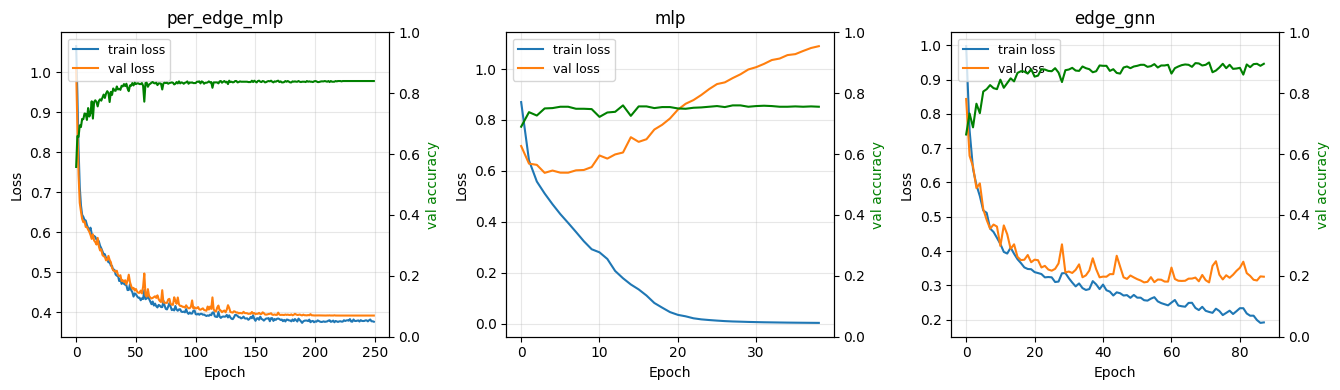

In [147]:
fig, axes = plt.subplots(1, len(CONFIG["architectures"]),
                          figsize=(4.5 * len(CONFIG["architectures"]), 4))
if len(CONFIG["architectures"]) == 1:
    axes = [axes]
for ax, arch in zip(axes, CONFIG["architectures"]):
    h = results[arch]["history"]
    ax.plot(h["train_loss"], label="train loss")
    ax.plot(h["val_loss"], label="val loss")
    ax2 = ax.twinx()
    ax2.plot(h["val_acc"], color="green", linewidth=1.5, label="val acc")
    ax2.set_ylim(0, 1)
    ax2.set_ylabel("val accuracy", color="green")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title(arch)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("classifier_training_curves.png", dpi=200)
plt.show()

## Confusion matrices on Network 1

These are now interpreted relative to `CONFIG["train_network"]`. If training on Network 2, Network 1 is the cross-anatomy target test set.


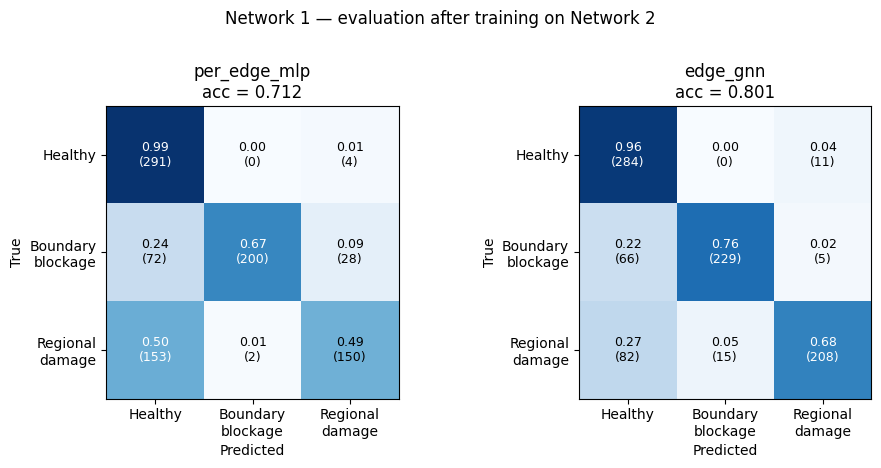

In [148]:
class_names = ["Healthy", "Boundary\nblockage", "Regional\ndamage"]

available = [a for a in CONFIG["architectures"] if results[a].get("metrics_net1") is not None]
if len(available) == 0:
    print("No Network 1 metrics available.")
else:
    fig, axes = plt.subplots(1, len(available),
                              figsize=(4.8 * len(available), 4.5))
    if len(available) == 1:
        axes = [axes]
    for ax, arch in zip(axes, available):
        cm = results[arch]["metrics_net1"]["confusion_matrix"]
        acc = results[arch]["metrics_net1"]["accuracy"]
        cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
        ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
        for i in range(3):
            for j in range(3):
                color = "white" if cm_norm[i, j] > 0.5 else "black"
                ax.text(j, i, f"{cm_norm[i, j]:.2f}\n({cm[i,j]})",
                        ha="center", va="center", color=color, fontsize=9)
        ax.set_xticks(range(3))
        ax.set_yticks(range(3))
        ax.set_xticklabels(class_names)
        ax.set_yticklabels(class_names)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(f"{arch}\nacc = {acc:.3f}")
    plt.suptitle(f"Network 1 — evaluation after training on Network {CONFIG['train_network']}", y=1.02)
    plt.tight_layout()
    plt.savefig("classifier_confusion_net1.png", dpi=200, bbox_inches="tight")
    plt.show()


## Network 2 evaluation

This section reports whatever Network 2 metrics were stored during the main experiment. If training on Network 2, this is the held-out in-distribution test set; if training on Network 1, this is the cross-anatomy test set.


In [149]:
print("Evaluation metrics were already computed during the main training loop.")
for arch in CONFIG["architectures"]:
    m1 = results[arch].get("metrics_net1")
    m2 = results[arch].get("metrics_net2")
    s1 = "N/A" if m1 is None else f"{m1['accuracy']:.3f}"
    s2 = "N/A" if m2 is None else f"{m2['accuracy']:.3f}"
    print(f"  {arch:14s} | Network 1 acc = {s1} | Network 2 acc = {s2}")


Evaluation metrics were already computed during the main training loop.
  per_edge_mlp   | Network 1 acc = 0.712 | Network 2 acc = 0.872
  mlp            | Network 1 acc = N/A | Network 2 acc = 0.761
  edge_gnn       | Network 1 acc = 0.801 | Network 2 acc = 0.907


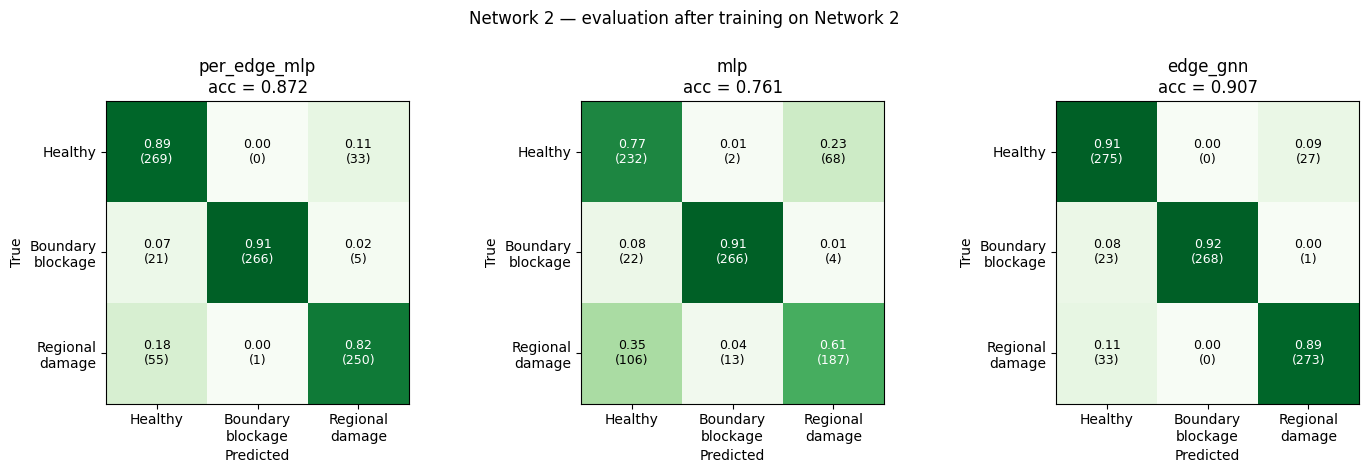

In [150]:
if ctx2 is not None:
    available = [a for a in CONFIG["architectures"]
                 if results[a].get("metrics_net2") is not None]
    if len(available) > 0:
        fig, axes = plt.subplots(1, len(available),
                                  figsize=(4.8 * len(available), 4.5))
        if len(available) == 1:
            axes = [axes]
        for ax, arch in zip(axes, available):
            cm = results[arch]["metrics_net2"]["confusion_matrix"]
            acc = results[arch]["metrics_net2"]["accuracy"]
            cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
            ax.imshow(cm_norm, cmap="Greens", vmin=0, vmax=1)
            for i in range(3):
                for j in range(3):
                    color = "white" if cm_norm[i, j] > 0.5 else "black"
                    ax.text(j, i, f"{cm_norm[i, j]:.2f}\n({cm[i,j]})",
                            ha="center", va="center", color=color, fontsize=9)
            ax.set_xticks(range(3))
            ax.set_yticks(range(3))
            ax.set_xticklabels(class_names)
            ax.set_yticklabels(class_names)
            ax.set_xlabel("Predicted"); ax.set_ylabel("True")
            ax.set_title(f"{arch}\nacc = {acc:.3f}")
        plt.suptitle(f"Network 2 — evaluation after training on Network {CONFIG['train_network']}", y=1.02)
        plt.tight_layout()
        plt.savefig("classifier_confusion_net2.png", dpi=200, bbox_inches="tight")
        plt.show()
    else:
        print("No Network 2 metrics available.")
else:
    print("Network 2 not available.")


## Summary: Network 1 vs Network 2 accuracy

The labels below are evaluation networks. With the default config, Network 2 is the training anatomy and Network 1 is the target cross-anatomy test.


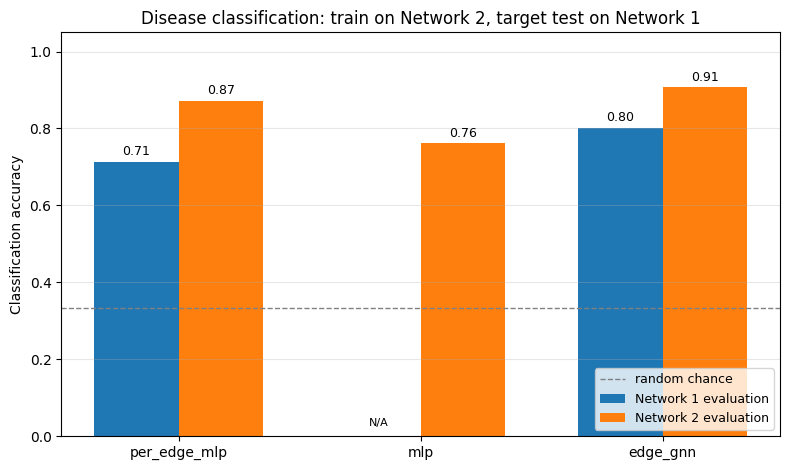


Per-class F1 (Network 1 evaluation):
  per_edge_mlp   | Healthy=0.718, Blockage=0.797, Regional=0.616
  mlp            | N/A
  edge_gnn       | Healthy=0.781, Blockage=0.842, Regional=0.786

Per-class F1 (Network 2 evaluation):
  per_edge_mlp   | Healthy=0.832, Blockage=0.952, Regional=0.842
  mlp            | Healthy=0.701, Blockage=0.928, Regional=0.662
  edge_gnn       | Healthy=0.869, Blockage=0.957, Regional=0.900


In [151]:
fig, ax = plt.subplots(figsize=(8, 4.8))
archs = CONFIG["architectures"]
x = np.arange(len(archs))
w = 0.35

def _acc_or_nan(metric):
    return np.nan if metric is None else metric["accuracy"]

acc_net1 = [_acc_or_nan(results[a].get("metrics_net1")) for a in archs]
acc_net2 = [_acc_or_nan(results[a].get("metrics_net2")) for a in archs]

plot_net1 = [0.0 if np.isnan(v) else v for v in acc_net1]
plot_net2 = [0.0 if np.isnan(v) else v for v in acc_net2]

bars1 = ax.bar(x - w/2, plot_net1, w, label="Network 1 evaluation")
bars2 = ax.bar(x + w/2, plot_net2, w, label="Network 2 evaluation")

for b, v in zip(bars1, acc_net1):
    if np.isnan(v):
        ax.text(b.get_x() + b.get_width()/2, 0.02, "N/A",
                ha="center", va="bottom", fontsize=8)
    else:
        ax.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.2f}",
                ha="center", va="bottom", fontsize=9)

for b, v in zip(bars2, acc_net2):
    if np.isnan(v):
        ax.text(b.get_x() + b.get_width()/2, 0.02, "N/A",
                ha="center", va="bottom", fontsize=8)
    else:
        ax.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.2f}",
                ha="center", va="bottom", fontsize=9)

ax.axhline(1/3, color="gray", linestyle="--", linewidth=1, label="random chance")
ax.set_xticks(x); ax.set_xticklabels(archs)
ax.set_ylabel("Classification accuracy")
ax.set_ylim(0, 1.05)
ax.set_title(f"Disease classification: train on Network {CONFIG['train_network']}, "
             f"target test on Network {CONFIG['test_network']}")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("classifier_accuracy_comparison.png", dpi=200)
plt.show()

# Print per-class F1.
print("\nPer-class F1 (Network 1 evaluation):")
for arch in CONFIG["architectures"]:
    m = results[arch].get("metrics_net1")
    if m is None:
        print(f"  {arch:14s} | N/A")
    else:
        f1 = m["f1_per_class"]
        print(f"  {arch:14s} | Healthy={f1[0]:.3f}, Blockage={f1[1]:.3f}, Regional={f1[2]:.3f}")

if ctx2 is not None:
    print("\nPer-class F1 (Network 2 evaluation):")
    for arch in CONFIG["architectures"]:
        m = results[arch].get("metrics_net2")
        if m is None:
            print(f"  {arch:14s} | N/A")
        else:
            f1 = m["f1_per_class"]
            print(f"  {arch:14s} | Healthy={f1[0]:.3f}, Blockage={f1[1]:.3f}, Regional={f1[2]:.3f}")


## Optional ablation: sweep the physics-flow feature weight

This tests how much the healthy physics-flow prior `y_healthy` helps or hurts cross-anatomy transfer. Use a small list first, because each value retrains the models.


In [152]:
# Optional: set RUN_PHYSICS_FLOW_SWEEP = True to run this ablation.
RUN_PHYSICS_FLOW_SWEEP = False
physics_flow_weight_grid = [0.0, 0.25, 0.5, 1.0, 2.0]

physics_flow_sweep_results = {}

if RUN_PHYSICS_FLOW_SWEEP:
    for w_phys in physics_flow_weight_grid:
        print(f"\n===== physics_flow_feature_weight = {w_phys} =====")

        ctx1_w = update_context_feature_weights(ctx1, physics_flow=w_phys)
        ctx2_w = update_context_feature_weights(ctx2, physics_flow=w_phys) if ctx2 is not None else None

        def get_weighted_bundle(net_id):
            if net_id == 1:
                return ctx1_w, train1, val1, test1
            if net_id == 2 and ctx2_w is not None:
                return ctx2_w, train2, val2, test2
            raise ValueError(f"Network {net_id} is not available.")

        ctx_train_w, train_set_w, val_set_w, train_test_set_w = get_weighted_bundle(TRAIN_NET)
        ctx_target_w, _, _, target_test_set_w = get_weighted_bundle(TEST_NET)

        physics_flow_sweep_results[w_phys] = {}
        for arch in CONFIG["architectures"]:
            if arch == "mlp" and ctx_train_w["E"] != ctx_target_w["E"]:
                # Train it if you want in-distribution only, but skip by default for speed.
                print(f"  {arch}: skipped in sweep because flat MLP cannot transfer across E.")
                continue

            params_w, model_w, hist_w = train_classifier(
                arch, ctx_train_w, train_set_w, val_set_w,
                hidden=CONFIG["hidden"], n_rounds=CONFIG["n_rounds"],
                n_epochs=CONFIG["n_epochs"],
                batch_size=CONFIG["batch_size"],
                lr=CONFIG["learning_rate"],
                seed=CONFIG["seed"],
                early_stop_patience=35,
                monitor="val_loss",
                verbose=False,
            )
            m_target = evaluate_classifier(params_w, model_w, ctx_target_w, target_test_set_w)
            physics_flow_sweep_results[w_phys][arch] = {
                "target_accuracy": m_target["accuracy"],
                "target_f1_macro": m_target["f1_macro"],
                "history": hist_w,
            }
            print(f"  {arch:14s} target acc={m_target['accuracy']:.3f}, "
                  f"target macro F1={m_target['f1_macro']:.3f}")
else:
    print("Physics-flow sweep disabled. Set RUN_PHYSICS_FLOW_SWEEP = True to run it.")


Physics-flow sweep disabled. Set RUN_PHYSICS_FLOW_SWEEP = True to run it.


In [153]:
artifacts = {
    "config": CONFIG,
    "results": {arch: {
        "train_network": results[arch].get("train_network"),
        "test_network": results[arch].get("test_network"),
        "metrics_train_network": results[arch].get("metrics_train_network"),
        "metrics_target_network": results[arch].get("metrics_target_network"),
        "metrics_net1": results[arch].get("metrics_net1"),
        "metrics_net2": results[arch].get("metrics_net2"),
        "history": results[arch]["history"],
    } for arch in CONFIG["architectures"]},
    "physics_flow_sweep_results": physics_flow_sweep_results,
}
with open("classifier_artifacts.pkl", "wb") as f:
    pickle.dump(artifacts, f)
print("Saved: classifier_artifacts.pkl")
print("Figures:")
for f in sorted(glob.glob("classifier_*.png")):
    print(" ", f)


Saved: classifier_artifacts.pkl
Figures:
  classifier_accuracy_comparison.png
  classifier_confusion_net1.png
  classifier_confusion_net2.png
  classifier_training_curves.png


In [154]:
# ============================================================
# Visualize network 1: diameters and flows for each class
# ============================================================
import pandas as pd
from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors

# Read node positions (the load function dropped them — recover from CSV).
nodes_df = pd.read_csv(str(DIR_NET1 / CONFIG["net1_files"]["node"])).sort_values("Node")
pos_arr  = nodes_df[["x", "y"]].to_numpy()
s_arr_np = np.asarray(ctx1["s_arr"])
t_arr_np = np.asarray(ctx1["t_arr"])
segments = np.stack([pos_arr[s_arr_np], pos_arr[t_arr_np]], axis=1)   # (E, 2, 2)

# Generate one sample per class with fixed seeds.
cfg_static_local = {
    "p_class":               jnp.asarray([1.0, 0.0, 0.0]),
    "healthy_jitter_max":    float(CONFIG["healthy_jitter_max"]),
    # Boundary blockage (new)
    "max_blocked":           int(CONFIG["max_blocked"]),
    "blockage_prob":         float(CONFIG["blockage_prob"]),
    "blockage_sev_lo":       float(CONFIG["blockage_severity_range"][0]),
    "blockage_sev_hi":       float(CONFIG["blockage_severity_range"][1]),
    # Regional damage
    "regional_hop_radius":   int(CONFIG["regional_hop_radius"]),
    "regional_sev_lo":       float(CONFIG["regional_severity_range"][0]),
    "regional_sev_hi":       float(CONFIG["regional_severity_range"][1]),
}

def sample_specific(label, seed):
    cfg = dict(cfg_static_local)
    cfg["p_class"] = jnp.zeros(3).at[label].set(1.0)
    s = sample_classified_pathology(jax.random.PRNGKey(seed), ctx1, cfg)
    return np.asarray(s.severity), np.asarray(s.flow_full)

sev_h, q_h = sample_specific(0, seed=42)    # Healthy
sev_b, q_b = sample_specific(1, seed=11)    # Boundary blockage
sev_r, q_r = sample_specific(2, seed=23)    # Regional damage

D_h = np.asarray(D_healthy1)
q_healthy_full = np.asarray(ctx1["q_healthy"])

samples = [("Healthy", sev_h, q_h),
           ("Boundary blockage", sev_b, q_b),
           ("Regional damage",   sev_r, q_r)]
all_D = [np.maximum(D_h * (1 - sev), 1e-3 * np.mean(D_h)) for _, sev, _ in samples]
all_Q = [np.asarray(q) for _, _, q in samples]

# 3 × 3 plot: diameters / flow magnitude / flow deviation from healthy
fig, axes = plt.subplots(3, 3, figsize=(16, 14))

# Row 1 — diameters
D_max = D_h.max()
norm_d = mcolors.Normalize(vmin=0, vmax=D_max)
for j, ((name, _, _), D) in enumerate(zip(samples, all_D)):
    ax = axes[0, j]
    colors = plt.cm.viridis(norm_d(D))
    widths = 0.3 + 3.0 * (D / D_max)
    ax.add_collection(LineCollection(segments, colors=colors, linewidths=widths))
    ax.set_xlim(pos_arr[:, 0].min(), pos_arr[:, 0].max())
    ax.set_ylim(pos_arr[:, 1].min(), pos_arr[:, 1].max())
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{name}\nDiameters", fontsize=11)
plt.colorbar(plt.cm.ScalarMappable(norm=norm_d, cmap="viridis"),
              ax=axes[0, :], shrink=0.7, label="diameter (μm)")

# Row 2 — |flow| on log color scale
all_abs_q = np.concatenate([np.abs(q) for q in all_Q])
positive_q = all_abs_q[all_abs_q > 1e-3]
q_min = max(np.quantile(positive_q, 0.05), 1e-3) if positive_q.size else 1e-3
q_max = positive_q.max() if positive_q.size else 1.0
norm_q = mcolors.LogNorm(vmin=q_min, vmax=q_max)
for j, ((name, _, _), q) in enumerate(zip(samples, all_Q)):
    ax = axes[1, j]
    qm = np.clip(np.abs(q), q_min, q_max)
    colors = plt.cm.plasma(norm_q(qm))
    widths = 0.4 + 2.6 * (np.log10(qm) - np.log10(q_min)) / max(np.log10(q_max) - np.log10(q_min), 1e-9)
    ax.add_collection(LineCollection(segments, colors=colors, linewidths=widths))
    ax.set_xlim(pos_arr[:, 0].min(), pos_arr[:, 0].max())
    ax.set_ylim(pos_arr[:, 1].min(), pos_arr[:, 1].max())
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{name}\nFlow magnitude |q|", fontsize=11)
plt.colorbar(plt.cm.ScalarMappable(norm=norm_q, cmap="plasma"),
              ax=axes[1, :], shrink=0.7, label="|q| (log scale)")

# Row 3 — relative deviation from healthy: (q - q_healthy) / max(|q_healthy|)
ref_scale = np.maximum(np.abs(q_healthy_full), q_min)
all_dev = [(q - q_healthy_full) / ref_scale for q in all_Q]
vmax_dev = max(np.quantile(np.abs(d), 0.98) for d in all_dev)
norm_dev = mcolors.Normalize(vmin=-vmax_dev, vmax=vmax_dev)
for j, ((name, _, _), dev) in enumerate(zip(samples, all_dev)):
    ax = axes[2, j]
    colors = plt.cm.RdBu_r(norm_dev(dev))
    widths = 0.4 + 2.6 * np.clip(np.abs(dev) / vmax_dev, 0, 1)
    ax.add_collection(LineCollection(segments, colors=colors, linewidths=widths))
    ax.set_xlim(pos_arr[:, 0].min(), pos_arr[:, 0].max())
    ax.set_ylim(pos_arr[:, 1].min(), pos_arr[:, 1].max())
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{name}\nFlow deviation (q − q_healthy)/|q_healthy|", fontsize=11)
plt.colorbar(plt.cm.ScalarMappable(norm=norm_dev, cmap="RdBu_r"),
              ax=axes[2, :], shrink=0.7, label="relative deviation")

plt.suptitle("Network 1: anatomy with pathology classes\n"
             "Row 1: Diameters  |  Row 2: Flow magnitude  |  Row 3: Flow deviation from healthy",
             fontsize=13, y=1.005)
plt.savefig("network1_pathology_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

KeyError: 'boundary_rescale_lo'

In [ ]:
# ============================================================
# Slide-ready extreme examples — direct selection (instant)
# ============================================================
import pandas as pd
from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors

# Node positions
nodes_df = pd.read_csv(str(DIR_NET1 / CONFIG["net1_files"]["node"])).sort_values("Node")
pos_arr  = nodes_df[["x", "y"]].to_numpy()
s_arr_np = np.asarray(ctx1["s_arr"])
t_arr_np = np.asarray(ctx1["t_arr"])
segments = np.stack([pos_arr[s_arr_np], pos_arr[t_arr_np]], axis=1)

q_h_full = np.asarray(ctx1["q_healthy"])
ref_scale = np.maximum(np.abs(q_h_full), 1.0)

# ── 1. Pick the major boundary node directly (largest |f_b|) ─────────
b_flows = np.asarray(net1.flow_boundary)
boundary_nodes_np = np.asarray(ctx1["boundary_nodes"])
b_mags = np.abs(b_flows[boundary_nodes_np])
top_idx = int(np.argmax(b_mags))
top_boundary_node = int(boundary_nodes_np[top_idx])
print(f"Major boundary node: {top_boundary_node}, |f_b| = {b_mags[top_idx]:.1f}")

# ── 2. Pick a regional-damage center: high-flow interior node ──────────
# Node "flow weight" = sum of |q_healthy| of its incident edges.
node_flow_weight = np.zeros(ctx1["N"])
for e, (s, t) in enumerate(zip(s_arr_np, t_arr_np)):
    node_flow_weight[s] += abs(q_h_full[e])
    node_flow_weight[t] += abs(q_h_full[e])
# Exclude boundary nodes — we want a regional damage inside the network.
candidates = np.argsort(node_flow_weight)[::-1]
center_node = next(int(c) for c in candidates if c not in boundary_nodes_np)
print(f"Regional damage center: {center_node}, incident |q| = {node_flow_weight[center_node]:.1f}")

# ── 3. Manually build the three severity fields and modified boundaries ─
N = ctx1["N"]
E = ctx1["E"]

# (a) Healthy: tiny jitter
rng = np.random.default_rng(42)
sev_h = rng.uniform(-0.02, 0.02, size=E)

# (b) Boundary blockage at top node, severity 0.95
sev_b = np.zeros(E)
edge_at_top = (s_arr_np == top_boundary_node) | (t_arr_np == top_boundary_node)
sev_b[edge_at_top] = 0.95

# Modified boundary flow with α = compensation_fraction (use 1.0 for max signal)
alpha = float(CONFIG["compensation_fraction"])
f_b = b_flows[top_boundary_node]
b_new = b_flows.copy()
b_new[top_boundary_node] = 0.0
is_other = (np.abs(b_flows) > 1e-6) & (np.arange(N) != top_boundary_node)
same = is_other & (np.sign(b_flows) == np.sign(f_b))
opp  = is_other & (np.sign(b_flows) == -np.sign(f_b))
b_new[same] += alpha * f_b / max(same.sum(), 1)
b_new[opp]  += (1 - alpha) * f_b / max(opp.sum(), 1)

# (c) Regional damage in 2-hop neighborhood of the high-flow interior node
d_from_center = np.asarray(ctx1["node_dist"][center_node])
in_region = (d_from_center[s_arr_np] <= CONFIG["regional_hop_radius"]) & \
            (d_from_center[t_arr_np] <= CONFIG["regional_hop_radius"])
sev_r = np.zeros(E)
sev_r[in_region] = 0.85
print(f"Region size: {int(in_region.sum())} edges out of {E}")

# ── 4. Solve physics for each case ──────────────────────────────────────
D_healthy_np = np.asarray(D_healthy1)
def D_path(sev):
    return jnp.asarray(np.maximum(D_healthy_np * (1 - sev), 1e-3 * D_healthy_np.mean()))

def solve_with_boundary(D, b):
    """Direct solve (avoids depending on edge_flow_with_boundary)."""
    C = np.asarray(net1.conductance(D))
    B = np.asarray(net1.B)
    L = B @ np.diag(C) @ B.T
    A = L.copy()
    rhs = np.asarray(b).copy()
    A[0, :] = 0; A[:, 0] = 0; A[0, 0] = 1.0
    rhs[0] = 0.0
    p = np.linalg.solve(A, rhs)
    return C * (B.T @ p)

q_h = np.asarray(net1.edge_flow(D_path(sev_h)))
q_b = solve_with_boundary(D_path(sev_b), b_new)
q_r = np.asarray(net1.edge_flow(D_path(sev_r)))

all_D = [np.asarray(D_path(s)) for s in [sev_h, sev_b, sev_r]]
all_Q = [q_h, q_b, q_r]
names = ["Healthy", "Boundary blockage\n(major node)", "Regional damage\n(high-flow region)"]

# ── 5. Plot (2 rows × 3 cols) ───────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: diameter ratio
norm_d = mcolors.Normalize(vmin=0, vmax=1.05)
for j, (name, D) in enumerate(zip(names, all_D)):
    ax = axes[0, j]
    ratio = D / D_healthy_np
    colors = plt.cm.RdYlGn(norm_d(ratio))
    widths = 0.6 + 2.4 * (D / D_healthy_np.max())
    ax.add_collection(LineCollection(segments, colors=colors, linewidths=widths))
    ax.set_xlim(pos_arr[:, 0].min(), pos_arr[:, 0].max())
    ax.set_ylim(pos_arr[:, 1].min(), pos_arr[:, 1].max())
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{name}\nDiameter ratio  D / D_healthy", fontsize=11)
plt.colorbar(plt.cm.ScalarMappable(norm=norm_d, cmap="RdYlGn"),
              ax=axes[0, :], shrink=0.7, label="diameter ratio (red = damaged)")

# Row 2: flow deviation
all_dev = [(q - q_h_full) / ref_scale for q in all_Q]
vmax_dev = max(0.5, max(np.quantile(np.abs(d), 0.98) for d in all_dev))
norm_dev = mcolors.Normalize(vmin=-vmax_dev, vmax=vmax_dev)
for j, (name, dev) in enumerate(zip(names, all_dev)):
    ax = axes[1, j]
    colors = plt.cm.RdBu_r(norm_dev(dev))
    widths = 0.5 + 2.5 * np.clip(np.abs(dev) / vmax_dev, 0, 1)
    ax.add_collection(LineCollection(segments, colors=colors, linewidths=widths))
    ax.set_xlim(pos_arr[:, 0].min(), pos_arr[:, 0].max())
    ax.set_ylim(pos_arr[:, 1].min(), pos_arr[:, 1].max())
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{name}\nFlow deviation (q − q_h) / |q_h|", fontsize=11)
plt.colorbar(plt.cm.ScalarMappable(norm=norm_dev, cmap="RdBu_r"),
              ax=axes[1, :], shrink=0.7,
              label="relative deviation (red = up, blue = down)")

plt.suptitle("Network 1 — extreme pathology examples for each class",
             fontsize=13, y=1.005)
plt.savefig("network1_extreme_pathology_examples.png", dpi=180, bbox_inches="tight")
plt.show()

Major boundary node: 181, |f_b| = 12045.2
Regional damage center: 195, incident |q| = 24090.5


KeyError: 'compensation_fraction'

## Interpretation guide

**What to look for:**

1. **Network 1 accuracy ranking.** If `edge_gnn` > `per_edge_mlp` > `mlp`, message passing helps detect spatial patterns. If `per_edge_mlp` is competitive with `edge_gnn`, the classification can be done from edge-local features alone.

2. **Per-class F1.**
   - *Healthy*: should be near-perfect. It's the null class.
   - *Boundary blockage*: should be detectable by all architectures — the boundary perturbation creates a distinctive flow magnitude shift visible even at observed edges.
   - *Regional damage*: the GNN should win here if it wins anywhere — the localized pattern needs message passing to detect.

3. **Cross-anatomy transfer.**
   - **`mlp` cannot transfer at all** (fixed E). This is the single strongest argument for the GNN over a flattened baseline.
   - **`per_edge_mlp` can transfer mechanically** but doesn't use topology, so its accuracy on Network 2 depends only on whether per-edge features are anatomy-invariant.
   - **`edge_gnn` is the only architecture that uses Network 2's actual topology.** If it transfers and per_edge_mlp doesn't, message passing learned topology-dependent features. If both transfer similarly, the classification signal lives mostly in marginal edge statistics.

**Interview headlines:**

- *In-distribution slide:* the three confusion matrices side-by-side, showing how the architectures partition the classes.
- *Cross-anatomy slide:* the bar chart + the two Network 2 confusion matrices. Emphasize that `mlp` is absent because architecture forbids transfer.
- *Narrative:* "The forward flow imputation problem on a redundant topology is too well-determined to be a fair test. The clinically valuable task is classification — detecting from sparse measurements whether the network shows a healthy, boundary, or regional signature. Here, message passing earns its keep because two of the three classes have spatial structure. And the GNN is the only architecture that transfers to a new anatomy zero-shot, which is the deployment story."